In [1]:
%%time
# Imports principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize

# Preprocesamiento y Métricas
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.pipeline import Pipeline

# --- OPTIMIZACIÓN CON GP_MINIMIZE ---
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

# --- CLASIFICADORES ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Ignorar advertencias de convergencia para mantener la salida limpia
import warnings
warnings.filterwarnings("ignore")

CPU times: user 3.74 s, sys: 298 ms, total: 4.04 s
Wall time: 3.1 s


In [2]:
# Función para cargar imágenes
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path): continue
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg'))]
        if max_per_class: files = files[:max_per_class]
        for f in files:
            img = imread(os.path.join(cls_path, f))
            if img.ndim == 3: img = img[...,0]
            img_resized = resize(img, size, anti_aliasing=True)
            X.append(img_resized)
            y.append(cls)
    return np.array(X), np.array(y), classes

# Carga
X, y_str, classes = load_image_dataset("CMS_data", size=(64,64))
print("Datos cargados.")

# Preprocesamiento
X = X / X.max()
X_flat = X.reshape(len(X), -1)

# Label Encoder
le = LabelEncoder()
y_int = le.fit_transform(y_str)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_int, test_size=0.2, stratify=y_int, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Binarización para ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

Datos cargados.
Train: (48000, 4096), Test: (12000, 4096)


In [3]:
def plot_multiclass_roc(y_test_bin, y_score, classes, title):
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None: plt.ylim(*ylim)
    plt.xlabel("Ejemplos de entrenamiento")
    plt.ylabel("Score (Accuracy)")
    
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="accuracy"
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True)
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r", label="Train Score")
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g", label="CV Score")
    plt.legend(loc="best")
    plt.show()

In [4]:
%%time
print("Optimizando KNN con gp_minimize...")

space_knn = [
    Integer(3, 20, name='n_neighbors'),
    Categorical(['uniform', 'distance'], name='weights')
]

@use_named_args(space_knn)
def objective_knn(**params):
    model = KNeighborsClassifier(n_jobs=-1, **params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return -np.mean(scores)

res_gp_knn = gp_minimize(objective_knn, space_knn, n_calls=10, random_state=42, verbose=True)

print(f"Mejor Accuracy (CV): {-res_gp_knn.fun:.4f}")
print(f"Mejores Parámetros: {res_gp_knn.x}")

Optimizando KNN con gp_minimize...
Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 196.7009
Function value obtained: -0.3470
Current minimum: -0.3470
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 194.1220
Function value obtained: -0.3702
Current minimum: -0.3702
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 196.1189
Function value obtained: -0.3696
Current minimum: -0.3702
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 196.0676
Function value obtained: -0.3696
Current minimum: -0.3702
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 195.2315
Function value obtained: -0.4542
Curre

In [5]:
best_params_knn = {
    'n_neighbors': res_gp_knn.x[0],
    'weights': res_gp_knn.x[1]
}

best_knn = KNeighborsClassifier(n_jobs=-1, **best_params_knn)
best_knn.fit(X_train, y_train)

y_pred_knn = best_knn.predict(X_test)
y_score_knn = best_knn.predict_proba(X_test)

print("--- Reporte KNN ---")
print(classification_report(y_test, y_pred_knn, target_names=classes))

--- Reporte KNN ---
              precision    recall  f1-score   support

    electron       0.52      0.75      0.61      2000
        muon       0.31      0.81      0.45      2000
    neutrino       1.00      0.19      0.32      2000
      proton       1.00      0.76      0.86      2000
       quark       1.00      0.80      0.89      2000
         tau       0.59      0.12      0.20      2000

    accuracy                           0.57     12000
   macro avg       0.74      0.57      0.55     12000
weighted avg       0.74      0.57      0.55     12000



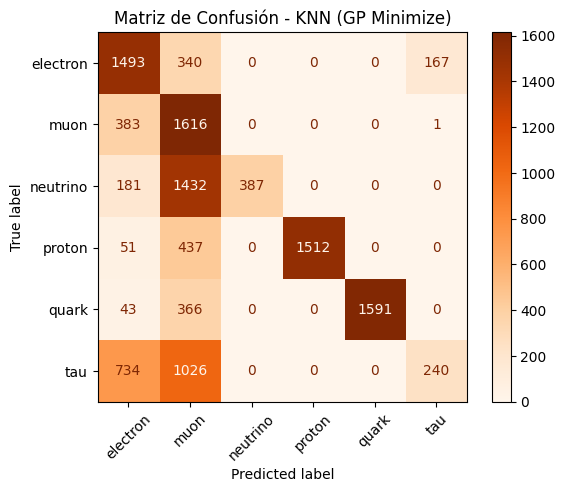

In [6]:
# Matriz
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn), display_labels=classes)
disp.plot(cmap="Oranges", xticks_rotation=45)
plt.title("Matriz de Confusión - KNN (GP Minimize)")
plt.show()

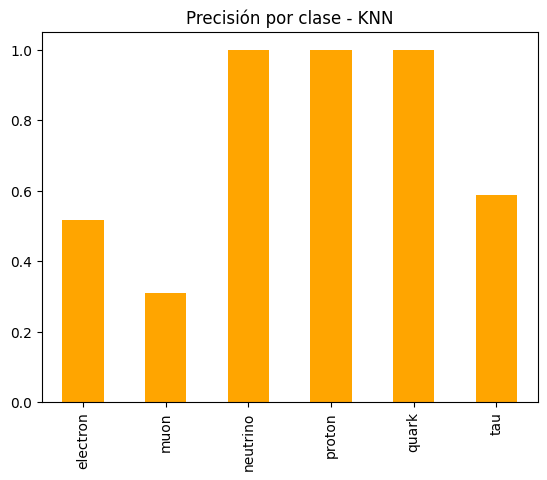

In [7]:
# Precisión
report = classification_report(y_test, y_pred_knn, output_dict=True, target_names=classes)
pd.DataFrame(report).transpose().loc[classes, "precision"].plot(kind="bar", color="orange")
plt.title("Precisión por clase - KNN")
plt.show()

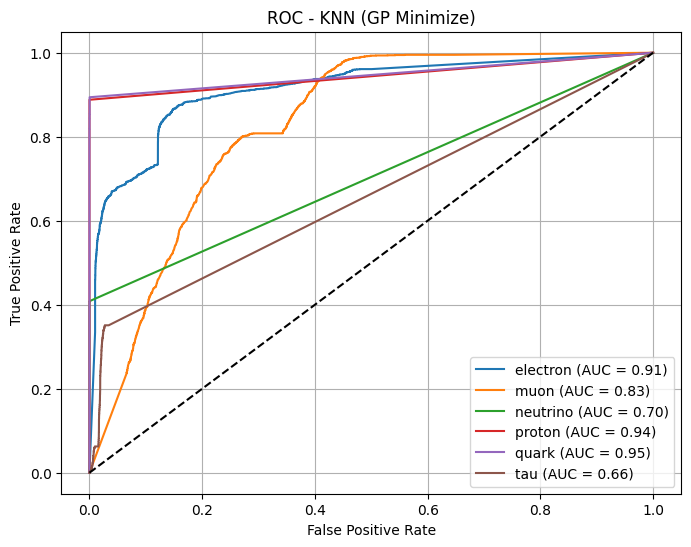

In [8]:
# ROC
plot_multiclass_roc(y_test_bin, y_score_knn, classes, "ROC - KNN (GP Minimize)")

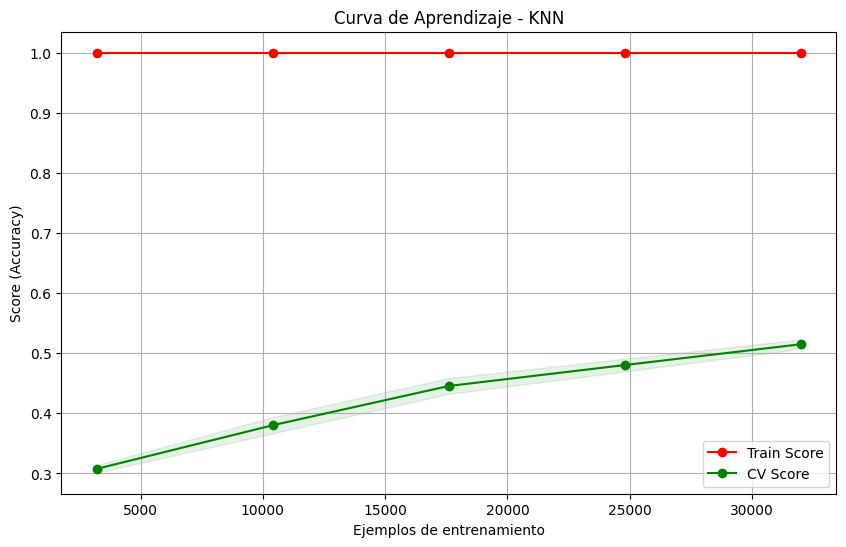

In [10]:
# Learning Curve
plot_learning_curve(best_knn, "Curva de Aprendizaje - KNN", X_train, y_train, cv=3)